## Maze Generation

### Imports

In [61]:
import random 
import numpy
import heapq
import pygame
import copy
import tkinter as tk
import matplotlib.pyplot as plt
import time
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from IPython.display import display, clear_output

### Classes
Two main classes: Maze (to generate the adjacency matrix), and Model (to draw maze)

In [2]:
""" Creates matrices (adj_matrix and maze_matrix) represnting a maze
Uses Prim's algorithm to randomly generate the maze
"""
class Maze:
    adj_matrix : list # for each (row, col): 0 = row vertex and col vertex are connected, 1 = they are not
    maze_matrix: list # 0 = empty box (agent can be there), 1 = wall
        # simplified version of maze, to test different kinds of inputs
    size : int
    weights : dict

    def __init__ (self, size):
        self.size = size
        self.size_sq = size * size # for convenience

        self.adj_matrix = [] # adjacency matrix; init: all 0s (nothing is connected)
        self._reset_adj_matrix()

        self.weights = {} # dictionary with weights for each vertex (ids 0 to size^2, represents vertices linearly)
        self._create_random_weights()

        self.create_random_adj_matrix()

    """
    Create dictionary with random weights for vertices
    """
    def _create_random_weights(self) -> None:
        self.weights = {} # contains weights of each vertex
        for i in range(self.size_sq + 1):
            self.weights[i] = random.random() # determine weight

    """
    Reset adjaceny matrix to all 0s.
    """
    def _reset_adj_matrix(self) -> None: 
        self.adj_matrix = []
        for i in range(self.size_sq):
            self.adj_matrix.append([0 for i in range(self.size_sq)])

    """
    Add frontier vertices with their weights to heap array.
    EFFECT: changes heap with highest weighted vertices
    """
    def _find_frontiers(self, vertex : int, heap : list, visited : list) -> None: # PURPOSE: find the frontiers for a given point
        frontiers = [] # left right top bottom

        if not (vertex)%self.size == 0 and vertex -1 >=0: # not on a border (right)
            frontiers.append(vertex-1)
        if not (vertex+1)%self.size ==0 and vertex+1 < self.size*self.size: # not on border (left)
            frontiers.append(vertex+1)
        if vertex-self.size >= 0: # not on border (top)
            frontiers.append(vertex-self.size)
        if vertex+self.size < self.size*self.size: # no on border (bottom)
            frontiers.append(vertex+self.size)

        for frontier in frontiers:
            if not frontier in visited and not (self.weights[frontier], frontier) in heap: # and if it's not already visited or in the heap
                heapq.heappush(heap, (self.weights[frontier], frontier))
                heapq._heapify_max(heap)

    """
    Find the points that have already been visited that the input point can connect to.
    
    Args: 
        vertex (int): integer value of the current vertex, increases linearly from left-right, top-down
        visited (list): array of integers that represent all the points already in the maze
    """
    # 
    # RETURN: one adjacent point to a vertex. 
    def _find_adj_maze_pts(self, vertex : int, visited : list) -> int:
        all_adj_pts = [] # possible adjacent maze pts

        if not (vertex)%self.size == 0 and vertex -1 >=0: # not on a border (right)
            all_adj_pts.append(vertex-1)
        if not (vertex+1)%self.size ==0 and vertex+1 < self.size_sq: # not on border (left)
            all_adj_pts.append(vertex+1)
        if vertex-self.size >= 0: # not on border (top)
            all_adj_pts.append(vertex-self.size)
        if vertex+self.size < self.size_sq: # no on border (bottom)
            all_adj_pts.append(vertex+self.size)


        adj_maze_pts = []

        for pt in all_adj_pts: # are any possible pts in the maze pts array
            if pt in visited: adj_maze_pts.append(pt)
        
        if len(adj_maze_pts) == 1:
            rand_index = 0
        else:
            rand_index = random.randint(0, len(adj_maze_pts)-1) # if more than one, randomly choose one of them
        
        return adj_maze_pts[rand_index] # return that point
    

    """
    Creates a random adjacency matrix.
    """
    def create_random_adj_matrix(self) -> None:
        heap = []
        visited = []   
        
        self._create_random_weights()
        self._reset_adj_matrix() # to 0s

        target_pt = 0 # pt of attention

        while len(heap) != 0 or target_pt == 0:
            visited.append(target_pt)

            self._find_frontiers(target_pt, heap, visited) # add frontiers to the heap
            chosen_frontier = heapq.heappop(heap) # take out frontier with the most weight
            adj_pt = self._find_adj_maze_pts(chosen_frontier[1], visited)
            self.adj_matrix[chosen_frontier[1]][adj_pt] = 1 # put a 1 in the adjaceny matrix
            self.adj_matrix[adj_pt][chosen_frontier[1]] = 1 
            target_pt = chosen_frontier[1] # pt of attention
        
        # self._generate_maze_matrix()

    """
    Create maze matrix from adj matrix.
    Requires: adj_matrix is created.
    """
    def _generate_maze_matrix(self) -> None:
        self.maze_matrix = [[0 for i in range(2*self.size-1)] for j in range(2*self.size-1)]

        # horizontal pass
        index = 0
        for i in range(0, 2*self.size-1, 2):
            for j in range(1, 2*self.size-1, 2):
                
                if self.adj_matrix[index][index+1] == 0:
                    self.maze_matrix[i][j] = 1
                index+=1
                if (index+1)%self.size ==0:
                    index+=1

        # vertical pass
        for i in range(1, 2*self.size-1, 2): # set dead spaces that only connect walls
            for j in range(1, 2*self.size-1, 2):
                self.maze_matrix[i][j] = 1

        index = 0
        for i in range(1, 2*self.size-1, 2):
            for j in range(0, 2*self.size-1, 2):
                if self.adj_matrix[index][index+self.size] == 0:
                    self.maze_matrix[i][j] = 1
                index+=1

        # add walls around the maze
        self.maze_matrix.insert(0, [1 for i in range(2*self.size-1)]) # top wall
        self.maze_matrix.append([1 for i in range(2*self.size-1)]) # bottom wall

        for i, row in enumerate(self.maze_matrix):
            row.insert(0, 1) # left wall
            row.append(1) # right wall

In [121]:
""" Handles drawing the entire maze (by representing the maze through Gridboxes).
"""
class View:
    fig : plt.Figure
    ax : plt.Axes

    adj_matrix : list[list[int]]
    size : int

    def __init__ (self, in_adj_matrix, in_size):
        self.adj_matrix = in_adj_matrix
        self.size = in_size

        self.fig = None
        self.reset()
    
    """
    Reset the fig and ax to be new.
    """
    def reset(self):
        if (self.fig != None):
            self.fig.clear()
        
        self.fig, self.ax = plt.subplots()
        self.ax.set_xticks([])
        self.ax.set_yticks([])

        self.ax.set_xlim(0, self.size)
        self.ax.set_ylim(0, self.size)

        self.ax.set_aspect('equal', adjustable='box') # ensure circles look like circles


    """
    Draw the maze without agent
    """
    def draw_maze(self):
        draw_grid = [Gridbox(vertex=i, size=self.size) for i in range(self.size*self.size)]

        for i, row in enumerate(self.adj_matrix):
            draw_grid[i].update_edges(row)
            draw_grid[i].add_edges_to_model(self)
        
        display(self.ax)
        clear_output(wait=True)

    """
    Draw the maze with an agent
    """
    def draw_maze_agent(self, x, y):
        draw_grid = [Gridbox(vertex=i, size=self.size) for i in range(self.size*self.size)]
        for i, row in enumerate(self.adj_matrix):
            draw_grid[i].update_edges(row)
            draw_grid[i].add_edges_to_model(self)

        # add agent
        agent = patches.Circle((x+0.5, y+0.5), radius = 0.25, color='blue')
        self.ax.add_patch(agent)

        display(self.ax)
        clear_output(wait=True)


In [120]:
""" Represents a single gridbox square with 4 edges. """
class Gridbox:
    edges : dict
    vertex : int
    size : int
    start : bool
    end : bool

    def __init__(self, vertex: int, size : int):
        self.edges = {
            'top': True,
            'bottom': True,
            'left': True,
            'right': True
        }
        self.vertex = vertex
        self.size = size
        
        self.start = vertex == 0
        self.end = vertex == size*size-1
    
    """
    Given it's adjaceny matrix row (showing its relationship with all other points), update whether walls are there.

    Args:
        adj_matrix_row (list[int]) : array of integers corresponding to the vertex from the adjacency matrix. In the array, the value of 1 means the vertices are connected.
    """
    def update_edges(self, adj_matrix_row : list[int]):
        indices = { 
            'top': self.vertex - self.size,
            'bottom': self.vertex + self.size,
            'left': self.vertex - 1,
            'right': self.vertex +1
        }
        for direction in ['top', 'bottom', 'left', 'right']:
            if indices[direction] < self.size*self.size and adj_matrix_row[indices[direction]] == 1: 
                self.edges[direction] = False

    def add_edges_to_model(self, view : View):
        x = self.vertex%self.size
        y = self.size - self.vertex//self.size - 1
        # print(x, y)
        # patches.Rectangle((x, y), width, height, color='<color>', alpha='<transparency>')

        if self.edges['top']:
            patch = patches.Rectangle((x, y+1), 1, 0, color='black')
            view.ax.add_patch(patch)
        if self.edges['bottom']:
            patch = patches.Rectangle((x, y), 1, 0, color='black')
            view.ax.add_patch(patch)
        if self.edges['left']:
            patch = patches.Rectangle((x, y), 0, 1, color='black')
            view.ax.add_patch(patch)
        if self.edges['right']:
            patch = patches.Rectangle((x+1, y), 0, 1, color='black')
            view.ax.add_patch(patch)
        
        # add special colors for the start and end
        if self.start:
            patch = patches.Rectangle((x, y), 1, 1, color='green')
            view.ax.add_patch(patch)
        elif self.end:
            patch = patches.Rectangle((x, y), 1, 1, color='red')
            view.ax.add_patch(patch)

            


### Testing Maze Generation & View

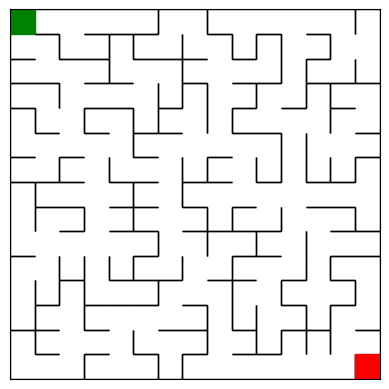

In [94]:
test_maze = Maze(size=15)
view = View(test_maze.adj_matrix, test_maze.size)
view.draw_maze()

## Training the RL agent

### Imports

In [96]:
from gymnasium import Env
from gymnasium.spaces import Discrete, Box, Tuple, MultiBinary, MultiDiscrete
from gymnasium.spaces import Dict as GymDict

import numpy as np 

import os
np.bool8 = np.bool_

from stable_baselines3 import PPO, DQN

### Test State

In [98]:
# Channels - a boolean array for each vertex to convey meaning (and to simplify the state)
# (index): meaning
# 0: wall up
# 1: wall right
# 2: wall down
# 3: wall left
# 4: visited
# 5: current
# *only 0s and 1s

test_size = 6
test_maze = Maze(test_size)
test_adj_matrix = test_maze.adj_matrix
test_state = [[False for i in range(6)] for j in range(test_size*test_size)]

for vertex, row in enumerate(test_state):
    row[0] = vertex-test_size < 0 or not test_adj_matrix[vertex][vertex-test_size]
    row[1] = vertex+1 >= test_size*test_size or not test_adj_matrix[vertex][vertex+1]
    row[2] = vertex+test_size >= test_size*test_size or not test_adj_matrix[vertex][vertex+test_size]
    row[3] = vertex-1 < 0 or not test_adj_matrix[vertex][vertex-1]

test_state

[[True, False, False, True, False, False],
 [True, True, False, False, False, False],
 [True, False, False, True, False, False],
 [True, False, True, False, False, False],
 [True, True, True, False, False, False],
 [True, True, False, True, False, False],
 [False, True, False, True, False, False],
 [False, False, False, True, False, False],
 [False, False, False, False, False, False],
 [True, True, False, False, False, False],
 [True, False, True, True, False, False],
 [False, True, False, False, False, False],
 [False, True, True, True, False, False],
 [False, True, False, True, False, False],
 [False, True, True, True, False, False],
 [False, False, False, True, False, False],
 [True, True, True, False, False, False],
 [False, True, False, True, False, False],
 [True, False, True, True, False, False],
 [False, True, False, False, False, False],
 [True, False, True, True, False, False],
 [False, True, False, False, False, False],
 [True, True, False, True, False, False],
 [False, True

### Maze Environment Class

In [99]:
""" Maze environment class
"""
class MazeEnv(Env):
    def __init__(self, size, set_adj_matrix = None):
        self.action_space = Discrete(4) # 0: up, 1: right, 2: down, 3: left
        self.size = size

        # set up observation space
        obs = Box(0, 1, shape=(size*size,6), dtype=np.bool8)
        self.observation_space = obs 

        # create adj_matrix
        if set_adj_matrix is None:
            maze = Maze(size)
            self.adj_matrix = maze.adj_matrix
        else:
            self.adj_matrix = set_adj_matrix
        self.set_adj_matrix = set_adj_matrix

        # set state
        self.state = self._create_state(self.size, self.adj_matrix)
        self.state[0][5] =  True # player starts
        
        # set length
        self.length = 20*self.size*self.size
        self.curr_cell = 0

    def _create_state (self, in_size, adj_matrix):
        # 0-3: up, right, down, left; 4: visited, 5: current
        size_sq = in_size*in_size
        res = [[False for i in range(6)] for j in range(size_sq)]

        for vertex, row in enumerate(res):
            row[0] = vertex-in_size < 0 or not adj_matrix[vertex][vertex-in_size]
            row[1] = vertex+1 >= size_sq or not adj_matrix[vertex][vertex+1]
            row[2] = vertex+in_size >= size_sq or not adj_matrix[vertex][vertex+in_size]
            row[3] = vertex-1 < 0 or not adj_matrix[vertex][vertex-1]
        return res

    def step(self, action):
        # set next cell based on action
        terminated = False
        reward = 0
        next_cell = self.curr_cell

        # check if it's a wall
        is_wall = self.state[self.curr_cell][action]
        if is_wall: # if wall, stay in place
            reward = -0.15
        
        # otherwise calculate next cell
        else:
            # reset current cell, update so it's visited
            self.state[self.curr_cell][5] = False # not current anymore
            self.state[self.curr_cell][4] = True # visited

            # calculate action's influence
            if action == 0: # up
                next_cell = next_cell - self.size
            elif action == 1: # right
                next_cell = next_cell + 1
            elif action == 2: # down
                next_cell =  next_cell + self.size  
            elif action == 3: # left
                next_cell = next_cell - 1
            
            # update state with next cell
            self.state[next_cell][5] = True

            # check if next cell already visited
            if self.state[next_cell][4]:
                reward = -0.02
            else: # successful move
                reward = 0.1 # 0.04
                self.state[next_cell][4] = True # mark as visited

                # check if next cell is the end
                if next_cell == (self.size*self.size-1):
                    reward = 10
                    terminated = True # if reached end
            
        # update curr_cell (state is already updated)
        self.curr_cell = next_cell # update current cell

        # update length
        self.length = self.length - 1
        truncated = self.length <= 0
        
        # random info
        info = {}

        return self.state, reward, terminated, truncated, info
    

    def reset(self, seed=None):
        # create adj_matrix and state
        if self.set_adj_matrix is None:
            maze = Maze(self.size)
            self.adj_matrix = maze.adj_matrix

       # set state
        self.state = self._create_state(self.size, self.adj_matrix)
        self.state[0][5] =  True # player starts
        
        # set length
        self.length = 10*self.size*self.size
        self.curr_cell = 0

        return self.state, {}

### Training

In [123]:
# Create maze to train agent on
training_maze_size = 12
training_maze = Maze(training_maze_size)
training_adj_matrix = training_maze.adj_matrix

In [124]:
# Initialize env and model variables
env = MazeEnv(training_maze_size, training_adj_matrix)
log_path = os.path.join('Training', 'Logs-Channels')
model = PPO('MlpPolicy', env, verbose=1, tensorboard_log=log_path) # PPO

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


In [125]:
# Run model training, save the model
model.learn(total_timesteps=120000)
model.save("./channels/maze-example")

Logging to Training/Logs-Channels/PPO_260
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 1.44e+03 |
|    ep_rew_mean     | -113     |
| time/              |          |
|    fps             | 7633     |
|    iterations      | 1        |
|    time_elapsed    | 0        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 1.44e+03    |
|    ep_rew_mean          | -115        |
| time/                   |             |
|    fps                  | 4651        |
|    iterations           | 2           |
|    time_elapsed         | 0           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.008064093 |
|    clip_fraction        | 0.0755      |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.38       |
|    explained_variance   | 0.

In [126]:
# TESTING: Test env, picking random actions, output score
# running = True 
# score = 0
# env.reset()

# index = 0
# while running:
#     index+=1
#     action = env.action_space.sample()
#     obs, reward, terminated, truncated, info = env.step(action)
#     score += reward
#     running = not terminated and not truncated

# score

In [127]:
# Example of continuing training model
# def continue_training_random_adj(num : int):
#     maze = Maze(training_maze_size)
#     env = MazeEnv(training_maze_size, maze.adj_matrix)
#     model = PPO.load('./channels/maze7-'+str(num), env=env, tensorboard_log=log_path)
#     model.learn(total_timesteps=50000)
#     model.save("./channels/maze7-"+str(num+1))

# for i in range(0, 30): # how many times training it with a random matrix
#     continue_training_random_adj(i)

## Visualize Model's Predictions

In [ ]:
# Load model
maze_size = 12 # CHANGE THIS BASED ON THE MAZE!
env = MazeEnv(maze_size)
model = PPO.load('./channels/maze-example', env=env)

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


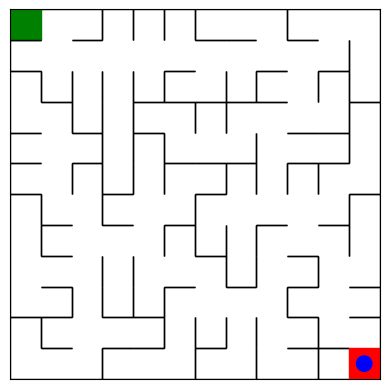

Maze is Completed
# of actions taken: 53


In [ ]:
# Setup visualization to test the model
def visualize_model(adj_matrix = None):
    # Create model
    if adj_matrix == None:
        adj_matrix = Maze(maze_size).adj_matrix # test on a random maze
    else:
        adj_matrix = adj_matrix # test on a specific maze (if trained only on one maze)

    # initialize agent pos, i j (for pygame), adj_matrix, and other variables
    agent_pos, i, j = 0, 0, 0
    running = True
    length = 0

    running_state = MazeEnv._create_state(None, maze_size, adj_matrix)
    running_state[0][5] =  True # player starts

    # draw maze
    view.draw_maze()

    # PURPOSE: update agent pos based on action
    def update_agent_pos(agent_pos, action):
        if action ==0: agent_pos -=maze_size
        elif action==1: agent_pos+=1
        elif action==2: agent_pos+=maze_size
        elif action==3: agent_pos-=1

        return agent_pos

    # Run window
    while running:
        # Draw the maze with agent
        i = agent_pos%maze_size
        j = agent_pos//maze_size
        view = View(adj_matrix, maze_size)
        view.draw_maze_agent(i, maze_size - j - 1)
        plt.show()

        # Check if agent completed the maze
        if agent_pos == maze_size*maze_size - 1:
            running = False
            print("Maze is Completed")
        
        # Predict the model's next move
        action = model.predict(running_state)[0]
        # print(action, agent_pos)

        # Check if move is valid
        is_wall = running_state[agent_pos][action]
        running_state[agent_pos][5] = False # not current anymore
        running_state[agent_pos][4] = True # visited

        # Update agent pos and state (check if the move is valid before updating - makes the code a lot cleaner)
        if not is_wall: agent_pos = update_agent_pos(agent_pos, action)
        running_state[agent_pos][5] = True # current
        
        # Buffer time
        time.sleep(0.1)
        length+=1

    print("# of actions taken:",length)